Loaded delta_in=2000: dapg_wolverine_stress_newparams_b20000_sift_k100_rounds5_T24_efC80_L2_K18_fi900000_fb20000_updrandom_new_vardefault_ef2100.csv
Loaded delta_in=5000: dapg_wolverine_stress_newparams_b5000_sift_k100_rounds5_T24_efC80_L2_K18_fi900000_fb5000_updrandom_new_vardefault_ef2100.csv
Loaded delta_in=10000: dapg_wolverine_stress_newparams_b10000_sift_k100_rounds5_T24_efC80_L2_K18_fi900000_fb10000_updrandom_new_vardefault_ef2100.csv
Loaded delta_in=20000: dapg_wolverine_stress_newparams_b20000_sift_k100_rounds5_T24_efC80_L2_K18_fi900000_fb20000_updrandom_new_vardefault_ef2100.csv


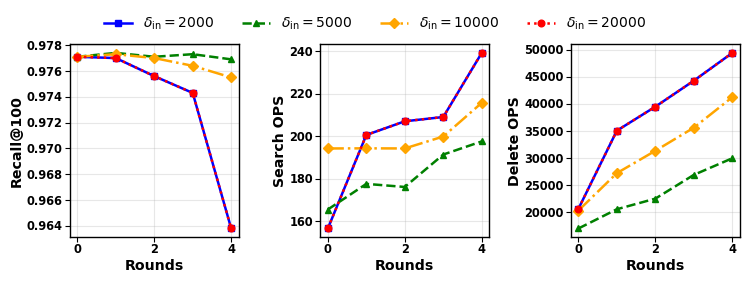

In [3]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(r"C:\Users\Soli1\SIGMOD\Solmaz\DAPG\cppCode\DAPG")
DYN = ROOT / "indexes" / "wolverine_exp"

blocks = [2000, 5000, 10000, 20000]

files = {}

for b in blocks:
    matches = sorted(
        DYN.glob(f"*stress_newparams_b{b}*updrandom_new_vardefault*.csv"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )

    if matches:
        files[b] = matches[0]
        print(f"Loaded delta_in={b}: {matches[0].name}")
    else:
        print(f"Missing delta_in={b}")

dfs = []

for delta, path in files.items():
    df = pd.read_csv(path)
    df["delta_in"] = delta
    df["source_file"] = path.name
    dfs.append(df)

if not dfs:
    raise RuntimeError("No stress-test files were loaded. Check DYN path or file names.")

stress = pd.concat(dfs, ignore_index=True)

style = {
    2000:  dict(color="blue", marker="s", linestyle="-"),
    5000:  dict(color="green", marker="^", linestyle="--"),
    10000: dict(color="orange", marker="D", linestyle="-."),
    20000: dict(color="red", marker="o", linestyle=":"),
}

metrics = [
    ("recall", "Recall@100"),
    ("search_OPS", "Search OPS"),
    ("delete_OPS", "Delete OPS"),
]



fig, axes = plt.subplots(1, 3, figsize=(7.6, 2.85), sharex=False)

for ax, (col, ylabel) in zip(axes, metrics):
    for delta in blocks:
        df = stress[stress["delta_in"] == delta].sort_values("round")

        if df.empty:
            continue

        y = pd.to_numeric(df[col], errors="coerce")

        ax.plot(
            df["round"],
            y,
            linewidth=1.8,
            markersize=4.8,
            label=rf"$\delta_{{\mathrm{{in}}}}={delta}$",
            **style.get(delta, {})
        )

    ax.set_xlabel("Rounds", fontsize=10.2, fontweight="bold", labelpad=2)
    ax.set_ylabel(ylabel, fontsize=10.2, fontweight="bold", labelpad=2)
    ax.grid(True, alpha=0.3, which="both")

    ax.tick_params(axis="both", labelsize=8.2, pad=1.5)

    for tick in ax.get_xticklabels():
        tick.set_fontweight("bold")
    for tick in ax.get_yticklabels():
        tick.set_fontweight("bold")

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)



handles, labels = axes[0].get_legend_handles_labels()

legend = fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    fontsize=10.0,
    frameon=False,
    bbox_to_anchor=(0.5, 1.00),
)

for text in legend.get_texts():
    text.set_fontweight("bold")

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.subplots_adjust(wspace=0.48)

out_png = DYN / "sift1m_delta_in_stress.png"
out_pdf = DYN / "sift1m_delta_in_stress.pdf"


plt.show()

